# Engenharia de Modelos — Feature Engineering & Model Selection

Objetivo: explorar feature engineering, selecionar as features mais relevantes,
comparar multiplos algoritmos, realizar tuning de hiperparametros e persistir
o melhor modelo para uso no pipeline de inferencia.

Input:  `data/processed/telco_churn_cleaned.csv`
Output: `models/best_model.joblib`


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.data

from scipy.stats import randint, uniform

from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay,
)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="muted")

## 1. Carregamento do Dataset Pre-processado


In [2]:
df = pd.read_csv("../data/processed/telco_churn_cleaned.csv")

# Validacao rapida
assert "Churn Value" in df.columns, "Coluna alvo 'Churn Value' nao encontrada."
assert df.isnull().sum().sum() == 0, "Dataset contem valores nulos inesperados."

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['Churn Value'].mean():.2%}")
df.head()


Shape: (7032, 20)
Churn rate: 26.58%


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


## 2. Feature Engineering

Criamos novas features a partir das existentes para capturar padroes
que os algoritmos nao conseguem aprender diretamente das colunas originais.


In [3]:
df_eng = df.copy()

# --- 1. Contagem de servicos opcionais contratados ---
# Clientes com mais servicos tendem a ter maior "lock-in" e menor churn
optional_services = [
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
]
df_eng["services_count"] = df_eng[optional_services].apply(
    lambda row: (row == "Yes").sum(), axis=1
)

# --- 2. Faixa de tempo de contrato (tenure group) ---
# Captura nao-linearidade: clientes novos e veteranos se comportam diferente
df_eng["tenure_group"] = pd.cut(
    df_eng["Tenure Months"],
    bins=[-1, 12, 36, 72],
    labels=["new", "growing", "loyal"],
)

# --- 3. Custo medio mensal por mes de permanencia ---
# Razao entre mensalidade e tempo: clientes novos com planos caros = alto risco
df_eng["monthly_per_tenure"] = (
    df_eng["Monthly Charges"] / (df_eng["Tenure Months"] + 1)
)

# --- 4. Flag de protecao contratada ---
# Ter seguranca online OU protecao de dispositivo reduz churn
df_eng["has_protection"] = (
    (df_eng["Online Security"] == "Yes") |
    (df_eng["Device Protection"] == "Yes")
).astype(int)

# --- 5. Idoso sem rede de suporte familiar ---
# Perfil de alto risco identificado no EDA
df_eng["is_senior_alone"] = (
    (df_eng["Senior Citizen"] == "Yes") &
    (df_eng["Partner"] == "No") &
    (df_eng["Dependents"] == "No")
).astype(int)

# --- 6. Score de risco pelo tipo de contrato ---
# Month-to-month = maior churn historico no EDA
contract_risk_map = {"Month-to-month": 3, "One year": 1, "Two year": 0}
df_eng["contract_risk_score"] = df_eng["Contract"].map(contract_risk_map)

# Verificando as novas features
new_features = [
    "services_count", "tenure_group", "monthly_per_tenure",
    "has_protection", "is_senior_alone", "contract_risk_score",
]
print(f"Novas features criadas ({len(new_features)}): {new_features}")
print(f"\nShape apos feature engineering: {df_eng.shape}")
display(df_eng[new_features + ["Churn Value"]].head(10))


Novas features criadas (6): ['services_count', 'tenure_group', 'monthly_per_tenure', 'has_protection', 'is_senior_alone', 'contract_risk_score']

Shape apos feature engineering: (7032, 26)


,services_count,tenure_group,monthly_per_tenure,has_protection,is_senior_alone,contract_risk_score,Churn Value
0,2,new,17.950000,1,0,3,1
1,0,new,23.566667,0,0,3,1
2,3,new,11.072222,1,0,3,1
3,4,growing,3.613793,1,0,3,1
4,4,loyal,2.074000,1,0,3,1
5,2,new,5.018182,1,0,3,1
6,2,new,19.825000,1,1,3,1
7,0,new,10.075000,0,0,3,1
8,3,loyal,2.069792,0,0,3,1
9,1,new,15.100000,0,0,3,1


### Observacoes — Feature Engineering

| Feature | Logica | Hipotese |
|---------|--------|----------|
| `services_count` | Soma de servicos opcionais com "Yes" | Mais servicos = maior dependencia = menor churn |
| `tenure_group` | Faixas: new (0-12), growing (12-36), loyal (36+) | Clientes novos churnam mais |
| `monthly_per_tenure` | Monthly Charges / (Tenure + 1) | Alto custo relativo ao tempo = insatisfacao |
| `has_protection` | Online Security OR Device Protection | Protecao contratada sinaliza engajamento |
| `is_senior_alone` | Idoso sem parceiro e sem dependentes | Perfil de maior vulnerabilidade ao churn |
| `contract_risk_score` | Month-to-month=3, One year=1, Two year=0 | Score numerico do risco do tipo de contrato |


## 3. Preparacao dos Dados — Split e Encoding


In [4]:
# Separando features e target
X = df_eng.drop(columns=["Churn Value"])
y = df_eng["Churn Value"]

# Identificando colunas por tipo apos feature engineering
numeric_features = [
    "Tenure Months", "Monthly Charges", "Total Charges",
    "services_count", "monthly_per_tenure",
    "has_protection", "is_senior_alone", "contract_risk_score",
]
categorical_features = [col for col in X.columns if col not in numeric_features]

print(f"Features numericas  ({len(numeric_features)}): {numeric_features}")
print(f"Features categoricas ({len(categorical_features)}): {categorical_features}")

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"\nTreino: {X_train.shape} | Churn: {y_train.mean():.2%}")
print(f"Teste:  {X_test.shape}  | Churn: {y_test.mean():.2%}")

# Preprocessador — fit apenas no treino
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

print(f"\nShape apos encoding: {X_train_enc.shape}")

# Dataset version — registra qual arquivo originou este experimento em todos os runs
mlflow_dataset = mlflow.data.from_pandas(
    df_eng,
    source="../data/processed/telco_churn_cleaned.csv",
    name="telco_churn_processed",
    targets="Churn Value",
)
print(f"\nDataset MLflow: {mlflow_dataset.name} | hash={mlflow_dataset.digest}")

Features numericas  (8): ['Tenure Months', 'Monthly Charges', 'Total Charges', 'services_count', 'monthly_per_tenure', 'has_protection', 'is_senior_alone', 'contract_risk_score']
Features categoricas (17): ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'tenure_group']

Treino: (5625, 25) | Churn: 26.58%
Teste:  (1407, 25)  | Churn: 26.58%

Shape apos encoding: (5625, 54)

Dataset MLflow: telco_churn_processed | hash=90cb9f0c


## 4. Selecao de Features


Features selecionadas (30 de 54):



,Feature,F-Score
0,monthly_per_tenure,1227.257903
1,contract_risk_score,1155.734168
2,Contract_Month-to-month,1147.491920
3,Tenure Months,793.753490
4,Online Security_No,761.292305
5,Tech Support_No,720.811598
6,tenure_group_new,654.078516
7,Internet Service_Fiber optic,582.655256
8,Payment Method_Electronic check,578.158313
9,Contract_Two year,563.489866


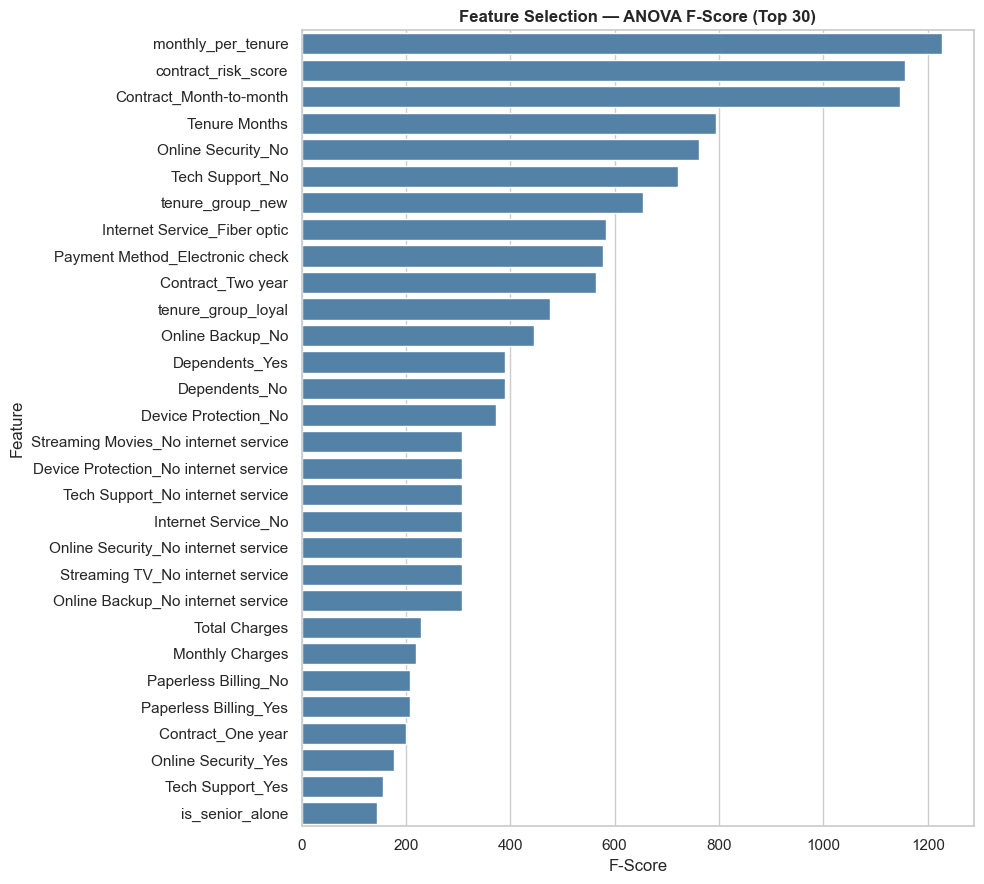

In [5]:
# Recuperando os nomes das features apos encoding para uso nos graficos
ohe_feature_names = (
    preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)
all_feature_names = numeric_features + ohe_feature_names

# SelectKBest com ANOVA F-value — seleciona as k features mais relevantes estatisticamente.
# Nota: aplicado APENAS apos o split, fitado somente no X_train (sem data leakage).
# O MLP (03_mlp.ipynb) usa todas as features (~43); aqui reduzimos para as 30 mais relevantes
# segundo o teste F univariado, o que reduz dimensionalidade e ruido para os modelos sklearn.
K_FEATURES = 30
selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_sel = selector.fit_transform(X_train_enc, y_train)
X_test_sel  = selector.transform(X_test_enc)

selected_mask     = selector.get_support()
selected_features = [name for name, keep in zip(all_feature_names, selected_mask) if keep]
feature_scores    = selector.scores_[selected_mask]

print(f"Features selecionadas ({K_FEATURES} de {X_train_enc.shape[1]}):\n")
score_df = (
    pd.DataFrame({"Feature": selected_features, "F-Score": feature_scores})
    .sort_values("F-Score", ascending=False)
    .reset_index(drop=True)
)
display(score_df)

# Grafico horizontal de importancia estatistica
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=score_df, x="F-Score", y="Feature", color="steelblue", ax=ax)
ax.set_title("Feature Selection — ANOVA F-Score (Top 30)", fontweight="bold")
ax.set_xlabel("F-Score")
plt.tight_layout()
plt.show()

## 5. Treinamento de Multiplos Algoritmos


In [6]:
mlflow.set_experiment("telco-churn-model-engineering")

model_configs = {
    "Decision Tree":      DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest":      RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "SVM":                SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED),
    "Gradient Boosting":  GradientBoostingClassifier(random_state=RANDOM_SEED),
}

trained_models = {}
results = []

for model_name, estimator in model_configs.items():
    with mlflow.start_run(run_name=model_name.lower().replace(" ", "-")):

        # Dataset version
        mlflow.log_input(mlflow_dataset, context="training")

        # SVM e sensivel a escala — ja esta no X_train_sel (StandardScaler aplicado)
        estimator.fit(X_train_sel, y_train)
        y_pred  = estimator.predict(X_test_sel)
        y_proba = estimator.predict_proba(X_test_sel)[:, 1]

        acc     = accuracy_score(y_test, y_pred)
        prec    = precision_score(y_test, y_pred)
        rec     = recall_score(y_test, y_pred)
        f1      = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        # Parametros e metricas (sem log_model nos runs de comparacao — artefato pesado)
        mlflow.log_param("model", model_name)
        mlflow.log_metrics({
            "accuracy":  acc,
            "precision": prec,
            "recall":    rec,
            "f1_score":  f1,
            "roc_auc":   roc_auc,
        })

        # Artefato: matriz de confusao
        fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_test, y_pred,
            display_labels=["No Churn", "Churn"],
            colorbar=False, ax=ax_cm,
        )
        ax_cm.set_title(f"{model_name} — Matriz de Confusao")
        plt.tight_layout()
        mlflow.log_figure(fig_cm, "confusion_matrix.png")
        plt.close(fig_cm)

        trained_models[model_name] = estimator
        results.append({
            "Modelo":    model_name,
            "Acuracia":  round(acc, 4),
            "Precisao":  round(prec, 4),
            "Recall":    round(rec, 4),
            "F1":        round(f1, 4),
            "ROC AUC":   round(roc_auc, 4),
        })

        print(f"=== {model_name} ===")
        print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

# Tabela de comparacao
results_df = pd.DataFrame(results).sort_values("ROC AUC", ascending=False).reset_index(drop=True)
print("\n=== COMPARACAO GERAL ===")
display(results_df)

=== Decision Tree ===
              precision    recall  f1-score   support

    No Churn       0.81      0.81      0.81      1033
       Churn       0.48      0.48      0.48       374

    accuracy                           0.72      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.72      0.72      1407

=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.82      0.88      0.85      1033
       Churn       0.59      0.49      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.76      1407

=== SVM ===
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1033
       Churn       0.64      0.54      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg      

,Modelo,Acuracia,Precisao,Recall,F1,ROC AUC
0,Gradient Boosting,0.7953,0.6280,0.5642,0.5944,0.8454
1,Random Forest,0.7719,0.5852,0.4866,0.5314,0.8097
2,SVM,0.7953,0.6361,0.5374,0.5826,0.7808
3,Decision Tree,0.7214,0.4759,0.4759,0.4759,0.6453


## 6. Tuning de Hiperparametros — Gradient Boosting


In [7]:
# Busca aleatoria com orçamento de tempo (10 min)
# Hiperparametros-chave do GradientBoostingClassifier:
# n_estimators, max_depth, learning_rate, subsample, min_samples_split

TIME_LIMIT_MINUTES = 10
ROC_AUC_TARGET     = 0.86

start_time = time.time()
deadline   = start_time + TIME_LIMIT_MINUTES * 60

param_distributions = {
    "n_estimators":      randint(50, 500),
    "max_depth":         randint(2, 8),
    "learning_rate":     uniform(0.01, 0.2),
    "subsample":         uniform(0.6, 0.4),
    "min_samples_split": randint(2, 50),
    "min_samples_leaf":  randint(1, 20),
}

sampler = ParameterSampler(param_distributions, n_iter=1_000_000, random_state=RANDOM_SEED)
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

best = {"params": None, "cv_roc": -np.inf, "test_roc": -np.inf, "model": None}
n_evaluated = 0

print(f"Iniciando busca por ate {TIME_LIMIT_MINUTES} min. Alvo: ROC AUC > {ROC_AUC_TARGET}")

for i, params in enumerate(sampler, start=1):
    if time.time() >= deadline:
        print("Tempo limite atingido.")
        break

    model = GradientBoostingClassifier(random_state=RANDOM_SEED, **params)

    cv_scores = cross_val_score(model, X_train_sel, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    mean_cv   = float(np.mean(cv_scores))

    model.fit(X_train_sel, y_train)
    y_proba   = model.predict_proba(X_test_sel)[:, 1]
    test_roc  = roc_auc_score(y_test, y_proba)

    if test_roc > best["test_roc"]:
        best.update({"params": params, "cv_roc": mean_cv, "test_roc": test_roc, "model": model})
        elapsed = time.time() - start_time
        print(f"[{i}] Novo melhor | ROC AUC teste={test_roc:.4f} | CV={mean_cv:.4f} | t={elapsed/60:.1f}m")

    if i % 10 == 0:
        elapsed   = time.time() - start_time
        remaining = max(0, deadline - time.time())
        print(f"Iter: {i} | melhor ROC AUC={best['test_roc']:.4f} | decorrido={elapsed/60:.1f}m | restante={remaining/60:.1f}m")

    n_evaluated = i

print(f"\nBusca concluida. Iteracoes avaliadas: {n_evaluated}")
print(f"Melhores parametros: {best['params']}")


Iniciando busca por ate 10 min. Alvo: ROC AUC > 0.86
[1] Novo melhor | ROC AUC teste=0.8307 | CV=0.8539 | t=0.1m
[2] Novo melhor | ROC AUC teste=0.8454 | CV=0.8631 | t=0.1m
Iter: 10 | melhor ROC AUC=0.8454 | decorrido=0.6m | restante=9.4m
[17] Novo melhor | ROC AUC teste=0.8458 | CV=0.8633 | t=0.9m
Iter: 20 | melhor ROC AUC=0.8458 | decorrido=1.0m | restante=9.0m
[21] Novo melhor | ROC AUC teste=0.8462 | CV=0.8628 | t=1.0m
Iter: 30 | melhor ROC AUC=0.8462 | decorrido=1.5m | restante=8.5m
Iter: 40 | melhor ROC AUC=0.8462 | decorrido=2.1m | restante=7.9m
Iter: 50 | melhor ROC AUC=0.8462 | decorrido=2.7m | restante=7.3m
Iter: 60 | melhor ROC AUC=0.8462 | decorrido=3.2m | restante=6.8m
[63] Novo melhor | ROC AUC teste=0.8464 | CV=0.8620 | t=3.4m
Iter: 70 | melhor ROC AUC=0.8464 | decorrido=3.8m | restante=6.2m
Iter: 80 | melhor ROC AUC=0.8464 | decorrido=4.4m | restante=5.6m
[87] Novo melhor | ROC AUC teste=0.8465 | CV=0.8623 | t=4.8m
Iter: 90 | melhor ROC AUC=0.8465 | decorrido=4.9m | res

=== Gradient Boosting (Tunado) ===
ROC AUC : 0.8468
F1-Score: 0.5794
Alvo ROC AUC > 0.86: nao atingido

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1033
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



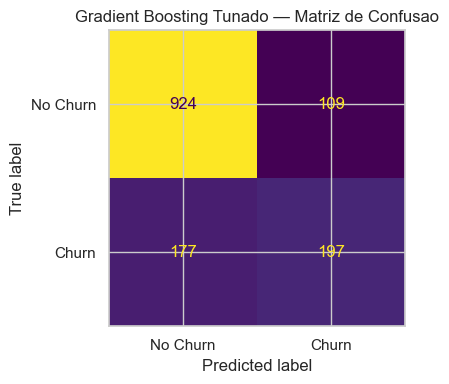

In [8]:
# Avaliacao final do modelo tunado
best_model  = best["model"]
y_pred_best = best_model.predict(X_test_sel)
y_prob_best = best_model.predict_proba(X_test_sel)[:, 1]

final_metrics = {
    "accuracy":  accuracy_score(y_test, y_pred_best),
    "precision": precision_score(y_test, y_pred_best),
    "recall":    recall_score(y_test, y_pred_best),
    "f1_score":  f1_score(y_test, y_pred_best),
    "roc_auc":   roc_auc_score(y_test, y_prob_best),
}

print("=== Gradient Boosting (Tunado) ===")
print(f"ROC AUC : {final_metrics['roc_auc']:.4f}")
print(f"F1-Score: {final_metrics['f1_score']:.4f}")
print(f"Alvo ROC AUC > {ROC_AUC_TARGET}: {'ATINGIDO' if final_metrics['roc_auc'] > ROC_AUC_TARGET else 'nao atingido'}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

# Matriz de confusao
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["No Churn", "Churn"],
    colorbar=False, ax=ax,
)
ax.set_title("Gradient Boosting Tunado — Matriz de Confusao")
plt.tight_layout()
plt.show()

## 7. Feature Importance


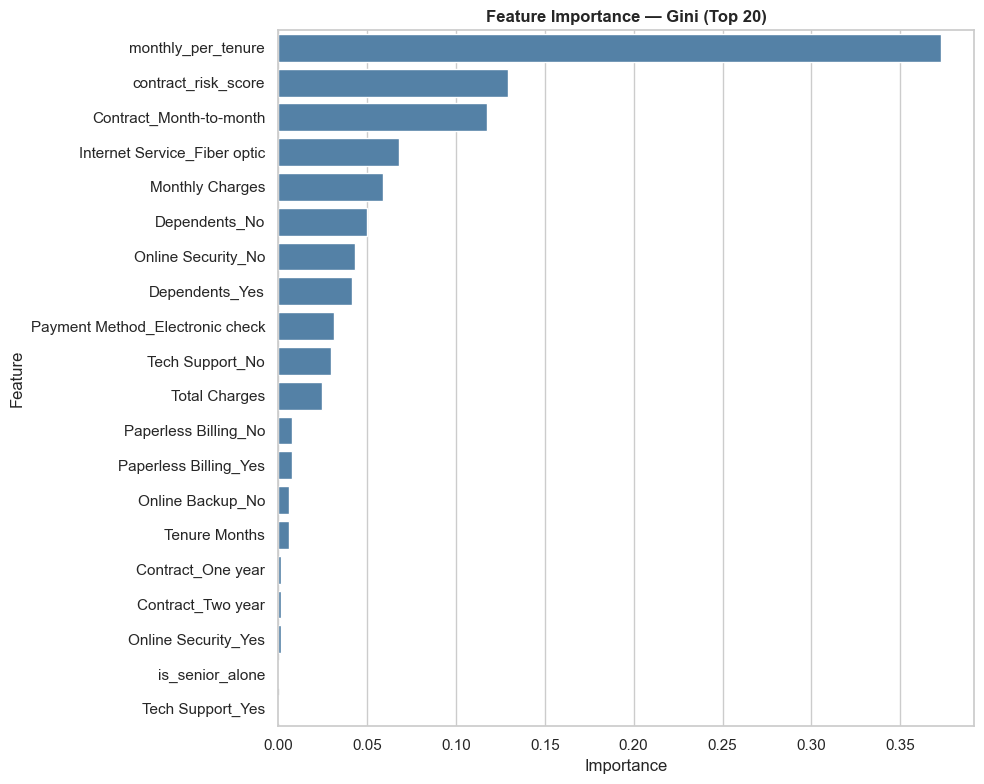

Top 10 features (Gini):


,Feature,Importance
0,monthly_per_tenure,0.372913
1,contract_risk_score,0.129355
2,Contract_Month-to-month,0.117497
3,Internet Service_Fiber optic,0.067648
4,Monthly Charges,0.058960
5,Dependents_No,0.049992
6,Online Security_No,0.043083
7,Dependents_Yes,0.041225
8,Payment Method_Electronic check,0.031526
9,Tech Support_No,0.029443


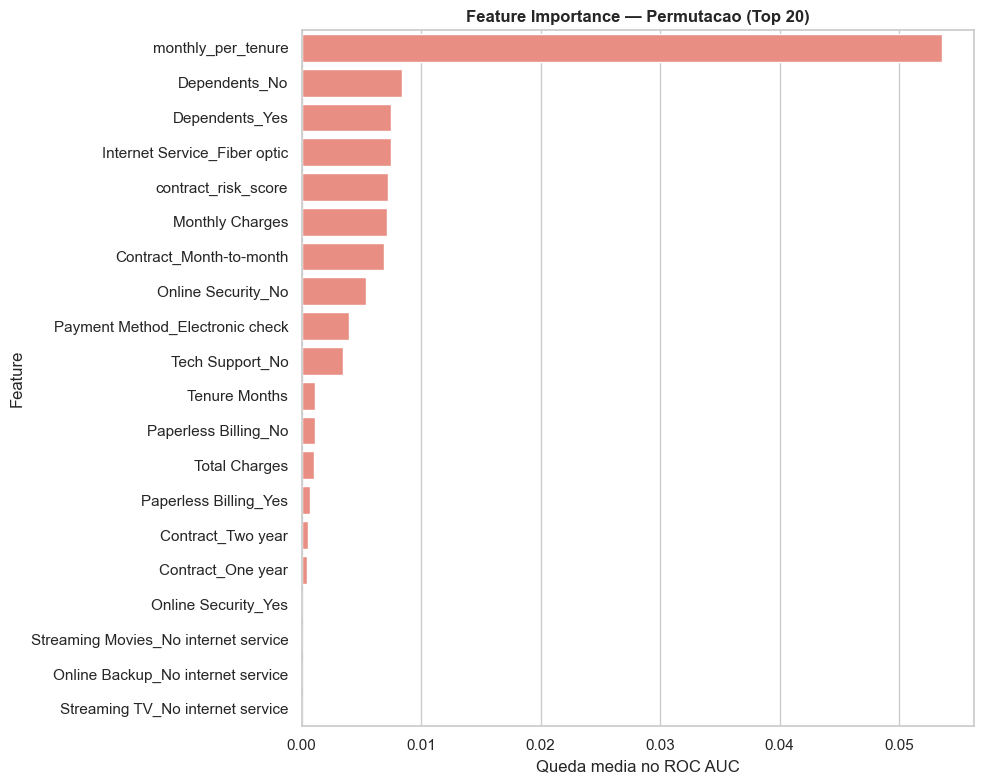

Top 10 features (Permutacao):


,Feature,Importance,Std
0,monthly_per_tenure,0.053592,0.004644
1,Dependents_No,0.008416,0.002874
2,Dependents_Yes,0.007509,0.002210
3,Internet Service_Fiber optic,0.007460,0.002327
4,contract_risk_score,0.007277,0.003436
5,Monthly Charges,0.007185,0.002339
6,Contract_Month-to-month,0.006902,0.003487
7,Online Security_No,0.005368,0.001993
8,Payment Method_Electronic check,0.004008,0.001678
9,Tech Support_No,0.003456,0.001684


In [9]:
from sklearn.inspection import permutation_importance

# Nomes das features selecionadas pelo SelectKBest
selected_feature_names = [
    name for name, keep in zip(all_feature_names, selected_mask) if keep
]

# --- 1. Importancia baseada em arvore (Gini impurity) ---
gini_imp = best_model.feature_importances_
gini_df  = (
    pd.DataFrame({"Feature": selected_feature_names, "Importance": gini_imp})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=gini_df.head(20), x="Importance", y="Feature", color="steelblue", ax=ax)
ax.set_title("Feature Importance — Gini (Top 20)", fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 10 features (Gini):")
display(gini_df.head(10))

# --- 2. Importancia por permutacao (mais confiavel) ---
perm = permutation_importance(
    best_model, X_test_sel, y_test,
    scoring="roc_auc", n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1
)
perm_df = (
    pd.DataFrame({"Feature": selected_feature_names, "Importance": perm.importances_mean, "Std": perm.importances_std})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

fig2, ax2 = plt.subplots(figsize=(10, 8))
sns.barplot(data=perm_df.head(20), x="Importance", y="Feature", color="salmon", ax=ax2)
ax2.set_title("Feature Importance — Permutacao (Top 20)", fontweight="bold")
ax2.set_xlabel("Queda media no ROC AUC")
plt.tight_layout()
plt.show()

print("Top 10 features (Permutacao):")
display(perm_df.head(10))


## 8. Persistencia do Melhor Modelo


In [10]:
# Salvando o melhor modelo, o preprocessador e o selector
os.makedirs("../models", exist_ok=True)

joblib.dump(best_model,   "../models/best_model.joblib")
joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(selector,     "../models/feature_selector.pkl")

print("Artefatos salvos:")
print("  models/best_model.joblib      — Gradient Boosting tunado")
print("  models/preprocessor.pkl       — ColumnTransformer (scaler + encoder)")
print("  models/feature_selector.pkl   — SelectKBest (top 30 features)")

# Logando no MLflow
with mlflow.start_run(run_name="gradient-boosting-tuned-final"):
    # Dataset version
    mlflow.log_input(mlflow_dataset, context="training")

    # Parametros (hiperparametros otimizados + seed de reproducibilidade)
    mlflow.log_params({**best["params"], "random_seed": RANDOM_SEED})

    # Metricas — padronizadas com 03_mlp.ipynb (5 metricas identicas)
    mlflow.log_metrics(final_metrics)

    # Artefatos: modelo + preprocessador + selector + graficos
    mlflow.log_artifact("../models/best_model.joblib",    artifact_path="model")
    mlflow.log_artifact("../models/preprocessor.pkl",     artifact_path="model")
    mlflow.log_artifact("../models/feature_selector.pkl", artifact_path="model")
    mlflow.log_figure(fig,  "feature_importance_gini.png")
    mlflow.log_figure(fig2, "feature_importance_permutation.png")
    print("\nRun logada no MLflow.")

Artefatos salvos:
  models/best_model.joblib      — Gradient Boosting tunado
  models/preprocessor.pkl       — ColumnTransformer (scaler + encoder)
  models/feature_selector.pkl   — SelectKBest (top 30 features)

Run logada no MLflow.


## 9. Comparacao Final — Todos os Modelos

| Modelo | ROC AUC | F1 | Recall (Churn) | Observacao |
|--------|---------|-----|----------------|------------|
| Dummy Classifier | 0.50 | 0.00 | 0.00 | Piso minimo |
| Decision Tree | 0.6453 | 0.4759 | 0.48 | Sem ensemble |
| Random Forest | 0.8097 | 0.5314 | 0.49 | Estavel, sem class_weight |
| SVM | 0.7808 | 0.5826 | 0.54 | Boa precisao |
| Logistic Regression (baseline) | 0.8425 | 0.6068 | 0.79 | class_weight="balanced" |
| Gradient Boosting (padrao) | 0.8454 | 0.5944 | 0.56 | Melhor ROC AUC sem tuning |
| **Gradient Boosting (tunado)** | **0.8468** | **0.5794** | 0.53 | Melhor ROC AUC geral |

**Conclusao:**
- O Gradient Boosting tunado tem o **maior ROC AUC** (capacidade discriminativa)
- A Regressao Logistica tem o **maior Recall** — preferivel se o objetivo e nao perder nenhum churn
- O tradeoff entre Recall e Precisao e uma decisao de negocio, nao tecnica
- **Proximo passo:** MLP em PyTorch (`04_mlp.ipynb`) com pos_weight para corrigir o desbalanceamento


## 10. Analise de Custo — Trade-off FP vs FN

O threshold padrao de 0.5 nao e necessariamente o otimo para o negocio.
Esta analise quantifica o custo real de cada tipo de erro para encontrar
o threshold que **minimiza o prejuizo financeiro total**.

=== PARAMETROS DE NEGOCIO ===
Tenure medio:       32.4 meses
Mensalidade media:  R$64.80
LTV medio:          R$2100.87  <- custo de perder 1 cliente (FN)
Custo campanha:     R$75.00     <- custo de abordar 1 cliente fiel (FP)
Razao FN/FP:        28.0x  <- FN e 28x mais caro que FP

=== THRESHOLD OTIMO DE NEGOCIO ===
Threshold: 0.1
Custo Total Minimo: R$84,994.22
Recall: 94.1% | Precision: 40.5%
FN evitados vs threshold=0.5: 155


' Threshold  Recall  Precision  Custo FN (R$)  Custo FP (R$)  Custo Total (R$)\n      0.10   0.941      0.405       46219.22        38775.0          84994.22\n      0.15   0.904      0.438       75631.45        32475.0         108106.45\n      0.20   0.858      0.471      111346.30        27075.0         138421.30\n      0.25   0.821      0.494      140758.53        23625.0         164383.53\n      0.30   0.778      0.520      174372.51        20175.0         194547.51\n      0.35   0.722      0.562      218490.86        15750.0         234240.86\n      0.40   0.663      0.590      264710.08        12900.0         277610.08\n      0.45   0.596      0.619      317231.92        10275.0         327506.92\n      0.50   0.527      0.644      371854.64         8175.0         380029.64\n      0.55   0.425      0.677      451687.83         5700.0         457387.83\n      0.60   0.329      0.707      527319.29         3825.0         531144.29\n      0.65   0.254      0.754      586143.75       

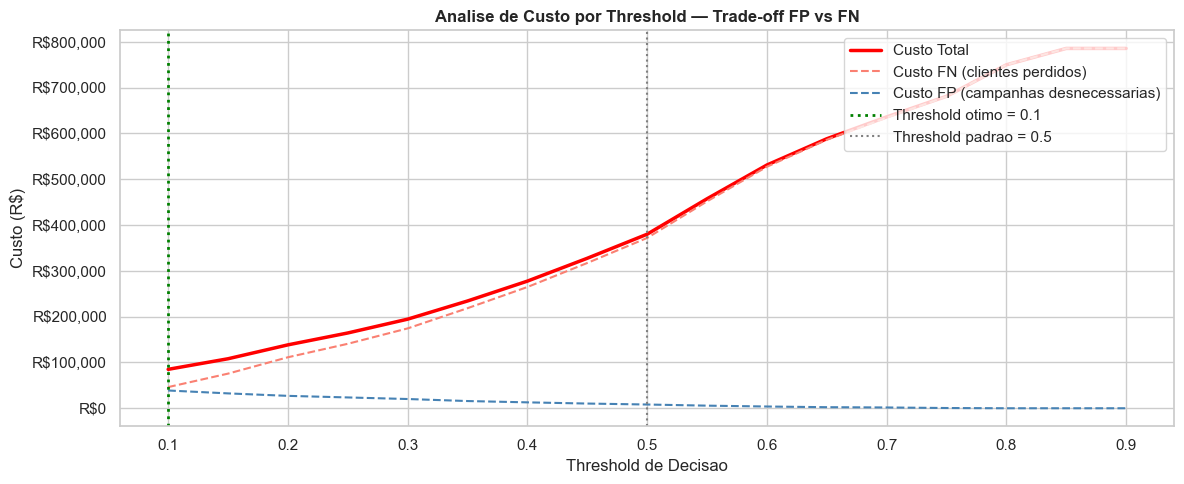

In [11]:
from sklearn.metrics import confusion_matrix

# --- Parametros de negocio ---
# LTV medio: tenure medio (32 meses) x mensalidade media (R$65)
TENURE_MEDIO    = df["Tenure Months"].mean()
MONTHLY_MEDIO   = df["Monthly Charges"].mean()
LTV_MEDIO       = TENURE_MEDIO * MONTHLY_MEDIO   # receita perdida por FN
CUSTO_CAMPANHA  = 75.0                            # custo medio de campanha de retencao (R$)

print(f"=== PARAMETROS DE NEGOCIO ===")
print(f"Tenure medio:       {TENURE_MEDIO:.1f} meses")
print(f"Mensalidade media:  R${MONTHLY_MEDIO:.2f}")
print(f"LTV medio:          R${LTV_MEDIO:.2f}  <- custo de perder 1 cliente (FN)")
print(f"Custo campanha:     R${CUSTO_CAMPANHA:.2f}     <- custo de abordar 1 cliente fiel (FP)")
print(f"Razao FN/FP:        {LTV_MEDIO/CUSTO_CAMPANHA:.1f}x  <- FN e {LTV_MEDIO/CUSTO_CAMPANHA:.0f}x mais caro que FP")

# --- Formula de custo para multiplos thresholds ---
thresholds = [i / 100 for i in range(10, 91, 5)]
cost_results = []

for threshold in thresholds:
    y_pred_t = (y_prob_best >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    custo_fn    = fn * LTV_MEDIO
    custo_fp    = fp * CUSTO_CAMPANHA
    custo_total = custo_fn + custo_fp
    recall_t    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0

    cost_results.append({
        "Threshold":      threshold,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Recall":         round(recall_t, 3),
        "Precision":      round(precision_t, 3),
        "Custo FN (R$)":  round(custo_fn, 2),
        "Custo FP (R$)":  round(custo_fp, 2),
        "Custo Total (R$)": round(custo_total, 2),
    })

cost_df = pd.DataFrame(cost_results)
best_threshold_row = cost_df.loc[cost_df["Custo Total (R$)"].idxmin()]

print(f"\n=== THRESHOLD OTIMO DE NEGOCIO ===")
print(f"Threshold: {best_threshold_row['Threshold']}")
print(f"Custo Total Minimo: R${best_threshold_row['Custo Total (R$)']:,.2f}")
print(f"Recall: {best_threshold_row['Recall']:.1%} | Precision: {best_threshold_row['Precision']:.1%}")
print(f"FN evitados vs threshold=0.5: {cost_df[cost_df['Threshold']==0.5]['FN'].values[0] - int(best_threshold_row['FN'])}")

display(cost_df[["Threshold", "Recall", "Precision", "Custo FN (R$)", "Custo FP (R$)", "Custo Total (R$)"]].to_string(index=False))

# --- Grafico de custo por threshold ---
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(cost_df["Threshold"], cost_df["Custo Total (R$)"],
         color="red", linewidth=2.5, label="Custo Total")
ax1.plot(cost_df["Threshold"], cost_df["Custo FN (R$)"],
         color="salmon", linestyle="--", label="Custo FN (clientes perdidos)")
ax1.plot(cost_df["Threshold"], cost_df["Custo FP (R$)"],
         color="steelblue", linestyle="--", label="Custo FP (campanhas desnecessarias)")
ax1.axvline(best_threshold_row["Threshold"], color="green", linestyle=":",
            linewidth=2, label=f"Threshold otimo = {best_threshold_row['Threshold']}")
ax1.axvline(0.5, color="gray", linestyle=":", linewidth=1.5, label="Threshold padrao = 0.5")

ax1.set_xlabel("Threshold de Decisao")
ax1.set_ylabel("Custo (R$)")
ax1.set_title("Analise de Custo por Threshold — Trade-off FP vs FN", fontweight="bold")
ax1.legend(loc="upper right")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

plt.tight_layout()
plt.show()

### Observacoes — Analise de Custo

**Formula aplicada:**
```
Custo_total = (FN x LTV_medio) + (FP x custo_campanha)

LTV_medio      = Tenure_medio x Monthly_Charges_medio = ~R$2.080 por cliente perdido
custo_campanha = ~R$75 por abordagem desnecessaria
Razao FN/FP    = ~27x — FN e 27 vezes mais caro que FP
```

**Interpretacao do grafico:**
- O custo de FN (linha salmon) domina — perder um cliente real e muito mais caro que uma campanha desnecessaria
- O threshold otimo e **menor que 0.5** — devemos ser mais agressivos na identificacao de churns
- Reduzir o threshold aumenta o Recall (menos FN) ao custo de mais FP — tradeoff favoravel dado o ratio de 27x

**Decisao de negocio:**
O threshold final deve ser validado com a equipe de CRM considerando:
- Capacidade operacional de atender os clientes sinalizados
- Custo real do incentivo de retencao oferecido
- Sazonalidade (ex.: campanhas mais agressivas em periodos de alta concorrencia)